# Hybrid Time Series Prediction: XGBoost + Meta-Labeling

**Architecture:**
1. **Base Model (XGBoost Regressor)** - Predicts next-day close price
2. **Meta-Model (Random Forest Classifier)** - Filters unreliable signals

**Assets:** AAPL, MSFT, EURUSD=X, BTC-USD, GC=F

**Metrics:**
- Base: RMSE, MAE
- Meta: Precision, Directional Accuracy, Sharpe Ratio

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import yfinance as yf
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    precision_score, accuracy_score, classification_report
)
import optuna
from optuna.samplers import TPESampler
import shap
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

print(f"Run date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Run date: 2026-01-11 14:16


## 1. Configuration

In [2]:
# === CONFIGURATION ===
TICKERS = ['AAPL', 'MSFT', 'EURUSD=X', 'BTC-USD', 'GC=F']
START_DATE = '2015-01-01'
END_DATE = None  # None = today

# Model parameters
TEST_SIZE = 0.2  # 20% test set
N_SPLITS_CV = 5  # TimeSeriesSplit folds
OPTUNA_TRIALS = 50  # Hyperparameter search trials

# Paths
DATA_DIR = '../data'
PLOTS_DIR = '../plots'
MODELS_DIR = '../models'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Results storage
RESULTS = {}

## 2. Data Loading & Feature Engineering

In [3]:
def fetch_data(ticker: str, start: str, end: str = None) -> pd.DataFrame:
    """Fetch OHLCV data with caching."""
    cache_file = os.path.join(DATA_DIR, f'{ticker.replace("=", "").replace("-", "")}_cache.csv')
    
    if os.path.exists(cache_file):
        df = pd.read_csv(cache_file, index_col=0, parse_dates=True)
        print(f"  Loaded {ticker} from cache ({len(df)} rows)")
    else:
        df = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df.to_csv(cache_file)
        print(f"  Downloaded {ticker} ({len(df)} rows)")
    
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    return df


def fetch_vix() -> pd.Series:
    """Fetch VIX (fear index) for market regime detection."""
    cache_file = os.path.join(DATA_DIR, 'VIX_cache.csv')
    
    if os.path.exists(cache_file):
        vix = pd.read_csv(cache_file, index_col=0, parse_dates=True)
    else:
        vix = yf.download('^VIX', start='2000-01-01', auto_adjust=False, progress=False)
        if isinstance(vix.columns, pd.MultiIndex):
            vix.columns = vix.columns.get_level_values(0)
        vix.to_csv(cache_file)
    
    if isinstance(vix.columns, pd.MultiIndex):
        vix.columns = vix.columns.get_level_values(0)
    
    return vix['Close'] if 'Close' in vix.columns else vix.iloc[:, 0]


def engineer_features(df: pd.DataFrame, vix: pd.Series = None) -> pd.DataFrame:
    """Create technical indicators and lag features."""
    df = df.copy()
    
    # Technical Indicators
    df['RSI'] = df.ta.rsi(length=14)
    df['SMA_20'] = df.ta.sma(length=20)
    df['SMA_50'] = df.ta.sma(length=50)
    df['ATR'] = df.ta.atr(length=14)
    df['Dist_SMA'] = (df['Close'] - df['SMA_50']) / df['SMA_50']
    
    # Bollinger Bands
    bb = df.ta.bbands(length=20, std=2)
    if bb is not None:
        bb_width_col = [c for c in bb.columns if 'BBB' in c]
        if bb_width_col:
            df['BB_Width'] = bb[bb_width_col[0]]
    
    # RSI Distance from neutral
    df['RSI_Dist'] = abs(df['RSI'] - 50)
    
    # Rolling volatility
    df['Rolling_Std'] = df['Close'].rolling(window=20).std()
    
    # Log returns
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    
    # Lag features
    for lag in [1, 2, 3, 5, 10]:
        df[f'Close_Lag_{lag}'] = df['Close'].shift(lag)
        df[f'Volume_Lag_{lag}'] = df['Volume'].shift(lag)
        df[f'Return_Lag_{lag}'] = df['Log_Return'].shift(lag)
    
    # Add VIX if available
    if vix is not None:
        df['VIX'] = vix
        df['VIX'] = df['VIX'].ffill().bfill()
        df['VIX_Slope'] = df['VIX'].diff(5)
        df['Panic_Mode'] = (df['VIX'] > 25).astype(int)
    
    # Target: Next day close
    df['Target'] = df['Close'].shift(-1)
    
    # Previous close (for signal generation)
    df['Prev_Close'] = df['Close'].shift(1)
    
    df.dropna(inplace=True)
    
    return df


def get_feature_columns(df: pd.DataFrame) -> list:
    """Get feature columns (exclude target and raw OHLCV)."""
    exclude = ['Target', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Prev_Close']
    return [col for col in df.columns if col not in exclude]

In [4]:
# Load VIX for all assets
print("Fetching VIX...")
VIX = fetch_vix()
print(f"VIX range: {VIX.index.min()} to {VIX.index.max()}\n")

# Load and prepare data for each ticker
DATASETS = {}

print("Loading asset data:")
for ticker in TICKERS:
    df = fetch_data(ticker, START_DATE, END_DATE)
    df = engineer_features(df, VIX)
    DATASETS[ticker] = df
    print(f"  {ticker}: {len(df)} samples, {len(get_feature_columns(df))} features")

print(f"\nTotal assets loaded: {len(DATASETS)}")

Fetching VIX...
VIX range: 2000-01-03 00:00:00 to 2025-12-12 00:00:00

Loading asset data:
  Loaded AAPL from cache (6527 rows)
  AAPL: 6477 samples, 27 features
  Downloaded MSFT (2772 rows)
  MSFT: 2722 samples, 27 features
  Downloaded EURUSD=X (2869 rows)
  EURUSD=X: 2819 samples, 27 features
  Downloaded BTC-USD (4029 rows)
  BTC-USD: 3979 samples, 27 features
  Downloaded GC=F (2771 rows)
  GC=F: 2721 samples, 27 features

Total assets loaded: 5


## 3. XGBoost Base Model with Optuna Tuning

In [5]:
def create_xgboost_objective(X_train, y_train, n_splits=5):
    """Create Optuna objective function for XGBoost hyperparameter tuning."""
    
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
            'random_state': 42
        }
        
        tscv = TimeSeriesSplit(n_splits=n_splits)
        scores = []
        
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = XGBRegressor(**params)
            model.fit(X_tr, y_tr, verbose=False)
            
            y_pred = model.predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            scores.append(rmse)
        
        return np.mean(scores)
    
    return objective


def train_xgboost_with_optuna(X_train, y_train, n_trials=50, n_splits=5):
    """Train XGBoost with Optuna hyperparameter optimization."""
    
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=42)
    )
    
    objective = create_xgboost_objective(X_train, y_train, n_splits)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    # Train final model with best params
    best_params = study.best_params
    best_params['random_state'] = 42
    
    model = XGBRegressor(**best_params)
    model.fit(X_train, y_train, verbose=False)
    
    return model, best_params, study.best_value

In [6]:
# Train XGBoost for each ticker
XGB_MODELS = {}
XGB_RESULTS = {}

for ticker in TICKERS:
    print(f"\n{'='*60}")
    print(f"Training XGBoost for {ticker}")
    print('='*60)
    
    df = DATASETS[ticker]
    feature_cols = get_feature_columns(df)
    
    X = df[feature_cols]
    y = df['Target']
    
    # Time-based split
    split_idx = int(len(df) * (1 - TEST_SIZE))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    print(f"\nRunning Optuna optimization ({OPTUNA_TRIALS} trials)...")
    
    # Train with Optuna
    model, best_params, cv_rmse = train_xgboost_with_optuna(
        X_train, y_train, 
        n_trials=OPTUNA_TRIALS, 
        n_splits=N_SPLITS_CV
    )
    
    # Evaluate on test set
    y_pred = model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    
    # Directional accuracy
    actual_direction = np.sign(y_test.values - df.loc[y_test.index, 'Prev_Close'].values)
    pred_direction = np.sign(y_pred - df.loc[y_test.index, 'Prev_Close'].values)
    dir_accuracy = accuracy_score(actual_direction, pred_direction)
    
    print(f"\nBest params: {best_params}")
    print(f"\nTest Results:")
    print(f"  RMSE: ${test_rmse:.4f}")
    print(f"  MAE:  ${test_mae:.4f}")
    print(f"  Directional Accuracy: {dir_accuracy:.2%}")
    
    XGB_MODELS[ticker] = model
    XGB_RESULTS[ticker] = {
        'model': model,
        'params': best_params,
        'cv_rmse': cv_rmse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'dir_accuracy': dir_accuracy,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'feature_cols': feature_cols
    }


Training XGBoost for AAPL
Train: 5181, Test: 1296

Running Optuna optimization (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best params: {'n_estimators': 226, 'max_depth': 3, 'learning_rate': 0.29775644435998916, 'subsample': 0.7449522079150063, 'colsample_bytree': 0.8658396864477416, 'min_child_weight': 4, 'gamma': 0.30181925708502183, 'reg_alpha': 0.0009446049729521626, 'reg_lambda': 2.5641909266120816e-07, 'random_state': 42}

Test Results:
  RMSE: $72.2104
  MAE:  $60.8019
  Directional Accuracy: 47.15%

Training XGBoost for MSFT
Train: 2177, Test: 545

Running Optuna optimization (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best params: {'n_estimators': 310, 'max_depth': 3, 'learning_rate': 0.08611571456873128, 'subsample': 0.8099259633101483, 'colsample_bytree': 0.6208517269046918, 'min_child_weight': 2, 'gamma': 0.916158762877907, 'reg_alpha': 1.039679848000202e-06, 'reg_lambda': 7.908342681931695e-05, 'random_state': 42}

Test Results:
  RMSE: $105.8400
  MAE:  $95.5363
  Directional Accuracy: 44.04%

Training XGBoost for EURUSD=X
Train: 2255, Test: 564

Running Optuna optimization (50 trials)...


...


Best params: {'n_estimators': 185, 'max_depth': 4, 'learning_rate': 0.03258000356329796, 'subsample': 0.8622187118198226, 'colsample_bytree': 0.907446179210497, 'min_child_weight': 7, 'gamma': 0.003820024587128462, 'reg_alpha': 2.0264470254351404e-05, 'reg_lambda': 0.0138476416294219, 'random_state': 42}

Test Results:
  RMSE: $0.0059
  MAE:  $0.0043
  Directional Accuracy: 70.21%

Training XGBoost for BTC-USD
Train: 3183, Test: 796

Running Optuna optimization (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best params: {'n_estimators': 244, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'subsample': 0.6557975442608167, 'colsample_bytree': 0.7168578594140873, 'min_child_weight': 4, 'gamma': 2.28034992108518, 'reg_alpha': 0.1165691561324743, 'reg_lambda': 6.267062696005991e-07, 'random_state': 42}

Test Results:
  RMSE: $30992.9342
  MAE:  $23244.1508
  Directional Accuracy: 54.77%

Training XGBoost for GC=F
Train: 2176, Test: 545

Running Optuna optimization (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best params: {'n_estimators': 161, 'max_depth': 3, 'learning_rate': 0.18055320783604892, 'subsample': 0.7738768683062107, 'colsample_bytree': 0.6240947224086655, 'min_child_weight': 10, 'gamma': 3.3030078315830633, 'reg_alpha': 1.3156710619460857e-06, 'reg_lambda': 5.902149029455729e-05, 'random_state': 42}

Test Results:
  RMSE: $1100.3616
  MAE:  $867.1474
  Directional Accuracy: 40.92%


In [7]:
# Summary table for XGBoost results
summary_data = []
for ticker, res in XGB_RESULTS.items():
    summary_data.append({
        'Ticker': ticker,
        'RMSE': f"${res['test_rmse']:.4f}",
        'MAE': f"${res['test_mae']:.4f}",
        'Dir. Accuracy': f"{res['dir_accuracy']:.2%}",
        'CV RMSE': f"${res['cv_rmse']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("XGBoost Base Model Summary")
print("="*60)
print(summary_df.to_string(index=False))


XGBoost Base Model Summary
  Ticker        RMSE         MAE Dir. Accuracy    CV RMSE
    AAPL    $72.2104    $60.8019        47.15%    $8.9536
    MSFT   $105.8400    $95.5363        44.04%   $32.8177
EURUSD=X     $0.0059     $0.0043        70.21%    $0.0193
 BTC-USD $30992.9342 $23244.1508        54.77% $7454.5608
    GC=F  $1100.3616   $867.1474        40.92%   $84.4458


## 4. Meta-Model (Signal Filter)

In [8]:
def create_meta_labels(df: pd.DataFrame, y_pred: np.ndarray, y_test: pd.Series) -> pd.DataFrame:
    """Create meta-labels based on XGBoost prediction correctness."""
    
    meta_df = df.loc[y_test.index].copy()
    meta_df['Predicted_Close'] = y_pred
    meta_df['Actual_Close'] = y_test
    
    # Signal from XGBoost: 1 = predicted UP, -1 = predicted DOWN
    meta_df['Signal'] = np.where(
        meta_df['Predicted_Close'] > meta_df['Prev_Close'], 1, -1
    )
    
    # Actual direction
    meta_df['Actual_Direction'] = np.where(
        meta_df['Actual_Close'] > meta_df['Prev_Close'], 1, -1
    )
    
    # Meta-Label: 1 if XGBoost was correct, 0 if wrong
    meta_df['Meta_Target'] = (meta_df['Signal'] == meta_df['Actual_Direction']).astype(int)
    
    # Model confidence feature
    meta_df['Model_Confidence'] = abs(
        meta_df['Predicted_Close'] - meta_df['Prev_Close']
    ) / meta_df['Prev_Close']
    
    return meta_df


def train_meta_model(meta_df: pd.DataFrame):
    """Train Random Forest classifier to filter unreliable signals."""
    
    # Features for meta-model
    meta_features = ['RSI', 'ATR', 'Rolling_Std', 'Model_Confidence']
    
    # Add VIX features if available
    if 'VIX' in meta_df.columns:
        meta_features.extend(['VIX', 'VIX_Slope'])
    if 'BB_Width' in meta_df.columns:
        meta_features.append('BB_Width')
    if 'RSI_Dist' in meta_df.columns:
        meta_features.append('RSI_Dist')
    
    # Filter to available features
    meta_features = [f for f in meta_features if f in meta_df.columns]
    
    X_meta = meta_df[meta_features]
    y_meta = meta_df['Meta_Target']
    
    # Split: first 50% for training meta-model, second 50% for evaluation
    split_idx = int(len(meta_df) * 0.5)
    X_m_train, X_m_test = X_meta.iloc[:split_idx], X_meta.iloc[split_idx:]
    y_m_train, y_m_test = y_meta.iloc[:split_idx], y_meta.iloc[split_idx:]
    
    # Train with GridSearch
    from sklearn.model_selection import GridSearchCV
    
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 4, 5],
        'min_samples_leaf': [3, 5, 10],
        'class_weight': ['balanced', None]
    }
    
    rf = RandomForestClassifier(random_state=42)
    grid = GridSearchCV(rf, param_grid, cv=3, scoring='precision', n_jobs=-1)
    grid.fit(X_m_train, y_m_train)
    
    meta_model = grid.best_estimator_
    
    return meta_model, meta_features, X_m_train, X_m_test, y_m_train, y_m_test


def calculate_trading_metrics(test_data: pd.DataFrame) -> dict:
    """Calculate Sharpe ratio and max drawdown."""
    
    def sharpe_ratio(returns):
        if returns.std() == 0:
            return 0
        return returns.mean() / returns.std() * np.sqrt(252)
    
    def max_drawdown(equity):
        peak = equity.cummax()
        drawdown = (equity - peak) / peak
        return drawdown.min()
    
    # Daily returns
    test_data['Return'] = (
        test_data['Actual_Close'] - test_data['Prev_Close']
    ) / test_data['Prev_Close']
    
    # Base strategy: follow all signals
    test_data['Strategy_Base'] = test_data['Return'] * test_data['Signal']
    
    # Meta strategy: only follow filtered signals
    test_data['Strategy_Meta'] = test_data['Strategy_Base'] * test_data['Meta_Filter']
    
    # Equity curves
    test_data['Equity_Base'] = (1 + test_data['Strategy_Base']).cumprod()
    test_data['Equity_Meta'] = (1 + test_data['Strategy_Meta']).cumprod()
    
    return {
        'sharpe_base': sharpe_ratio(test_data['Strategy_Base']),
        'sharpe_meta': sharpe_ratio(test_data['Strategy_Meta']),
        'maxdd_base': max_drawdown(test_data['Equity_Base']),
        'maxdd_meta': max_drawdown(test_data['Equity_Meta']),
        'total_return_base': test_data['Equity_Base'].iloc[-1] - 1,
        'total_return_meta': test_data['Equity_Meta'].iloc[-1] - 1
    }

In [9]:
# Train Meta-Model for each ticker
META_RESULTS = {}

for ticker in TICKERS:
    print(f"\n{'='*60}")
    print(f"Training Meta-Model for {ticker}")
    print('='*60)
    
    df = DATASETS[ticker]
    xgb_res = XGB_RESULTS[ticker]
    
    # Create meta-labels
    meta_df = create_meta_labels(df, xgb_res['y_pred'], xgb_res['y_test'])
    
    base_accuracy = meta_df['Meta_Target'].mean()
    print(f"Base model directional accuracy: {base_accuracy:.2%}")
    
    # Train meta-model
    meta_model, meta_features, X_m_train, X_m_test, y_m_train, y_m_test = train_meta_model(meta_df)
    
    # Predict on test portion
    meta_preds = meta_model.predict(X_m_test)
    
    # Metrics
    precision = precision_score(y_m_test, meta_preds, zero_division=0)
    accuracy = accuracy_score(y_m_test, meta_preds)
    
    print(f"\nMeta-Model Results:")
    print(f"  Precision (when we say 'trade'): {precision:.2%}")
    print(f"  Accuracy: {accuracy:.2%}")
    print(f"  Features used: {meta_features}")
    
    # Feature importance
    importances = pd.Series(
        meta_model.feature_importances_, 
        index=meta_features
    ).sort_values(ascending=False)
    print(f"\nFeature Importance:")
    for feat, imp in importances.items():
        print(f"  {feat}: {imp:.3f}")
    
    # Calculate trading metrics
    test_portion = meta_df.iloc[int(len(meta_df) * 0.5):].copy()
    test_portion['Meta_Filter'] = meta_preds
    trading_metrics = calculate_trading_metrics(test_portion)
    
    print(f"\nTrading Metrics:")
    print(f"  Base Strategy - Sharpe: {trading_metrics['sharpe_base']:.2f}, MaxDD: {trading_metrics['maxdd_base']:.2%}")
    print(f"  Meta Strategy - Sharpe: {trading_metrics['sharpe_meta']:.2f}, MaxDD: {trading_metrics['maxdd_meta']:.2%}")
    
    if precision > base_accuracy:
        print(f"\n  SUCCESS: Meta-filter improves precision by {precision - base_accuracy:.2%}")
    else:
        print(f"\n  NOTE: Meta-filter needs more tuning")
    
    META_RESULTS[ticker] = {
        'model': meta_model,
        'meta_features': meta_features,
        'precision': precision,
        'accuracy': accuracy,
        'base_accuracy': base_accuracy,
        'trading_metrics': trading_metrics,
        'feature_importance': importances,
        'X_m_test': X_m_test,
        'y_m_test': y_m_test,
        'meta_preds': meta_preds,
        'test_data': test_portion
    }


Training Meta-Model for AAPL
Base model directional accuracy: 47.15%

Meta-Model Results:
  Precision (when we say 'trade'): 53.85%
  Accuracy: 58.64%
  Features used: ['RSI', 'ATR', 'Rolling_Std', 'Model_Confidence', 'VIX', 'VIX_Slope', 'BB_Width', 'RSI_Dist']

Feature Importance:
  RSI: 0.228
  VIX_Slope: 0.153
  ATR: 0.124
  RSI_Dist: 0.123
  VIX: 0.112
  Model_Confidence: 0.111
  Rolling_Std: 0.089
  BB_Width: 0.061

Trading Metrics:
  Base Strategy - Sharpe: -1.18, MaxDD: -75.17%
  Meta Strategy - Sharpe: 0.89, MaxDD: -35.54%

  SUCCESS: Meta-filter improves precision by 6.70%

Training Meta-Model for MSFT
Base model directional accuracy: 44.04%

Meta-Model Results:
  Precision (when we say 'trade'): 59.44%
  Accuracy: 61.90%
  Features used: ['RSI', 'ATR', 'Rolling_Std', 'Model_Confidence', 'VIX', 'VIX_Slope', 'BB_Width', 'RSI_Dist']

Feature Importance:
  Model_Confidence: 0.239
  VIX_Slope: 0.186
  RSI: 0.143
  Rolling_Std: 0.094
  RSI_Dist: 0.094
  BB_Width: 0.084
  VIX: 0.08

In [10]:
# Summary table for Meta-Model results
meta_summary = []
for ticker, res in META_RESULTS.items():
    tm = res['trading_metrics']
    meta_summary.append({
        'Ticker': ticker,
        'Base Dir. Acc.': f"{res['base_accuracy']:.2%}",
        'Meta Precision': f"{res['precision']:.2%}",
        'Sharpe (Base)': f"{tm['sharpe_base']:.2f}",
        'Sharpe (Meta)': f"{tm['sharpe_meta']:.2f}",
        'Improvement': f"{res['precision'] - res['base_accuracy']:+.2%}"
    })

meta_summary_df = pd.DataFrame(meta_summary)
print("\n" + "="*60)
print("Meta-Model Summary: Base vs. Meta-Filtered Strategy")
print("="*60)
print(meta_summary_df.to_string(index=False))


Meta-Model Summary: Base vs. Meta-Filtered Strategy
  Ticker Base Dir. Acc. Meta Precision Sharpe (Base) Sharpe (Meta) Improvement
    AAPL         47.15%         53.85%         -1.18          0.89      +6.70%
    MSFT         44.04%         59.44%         -0.63          2.77     +15.40%
EURUSD=X         70.21%         70.70%          5.80          5.52      +0.48%
 BTC-USD         54.77%         53.28%          0.01          1.13      -1.50%
    GC=F         41.10%         45.36%         -3.64         -0.99      +4.25%


## 5. Visualizations

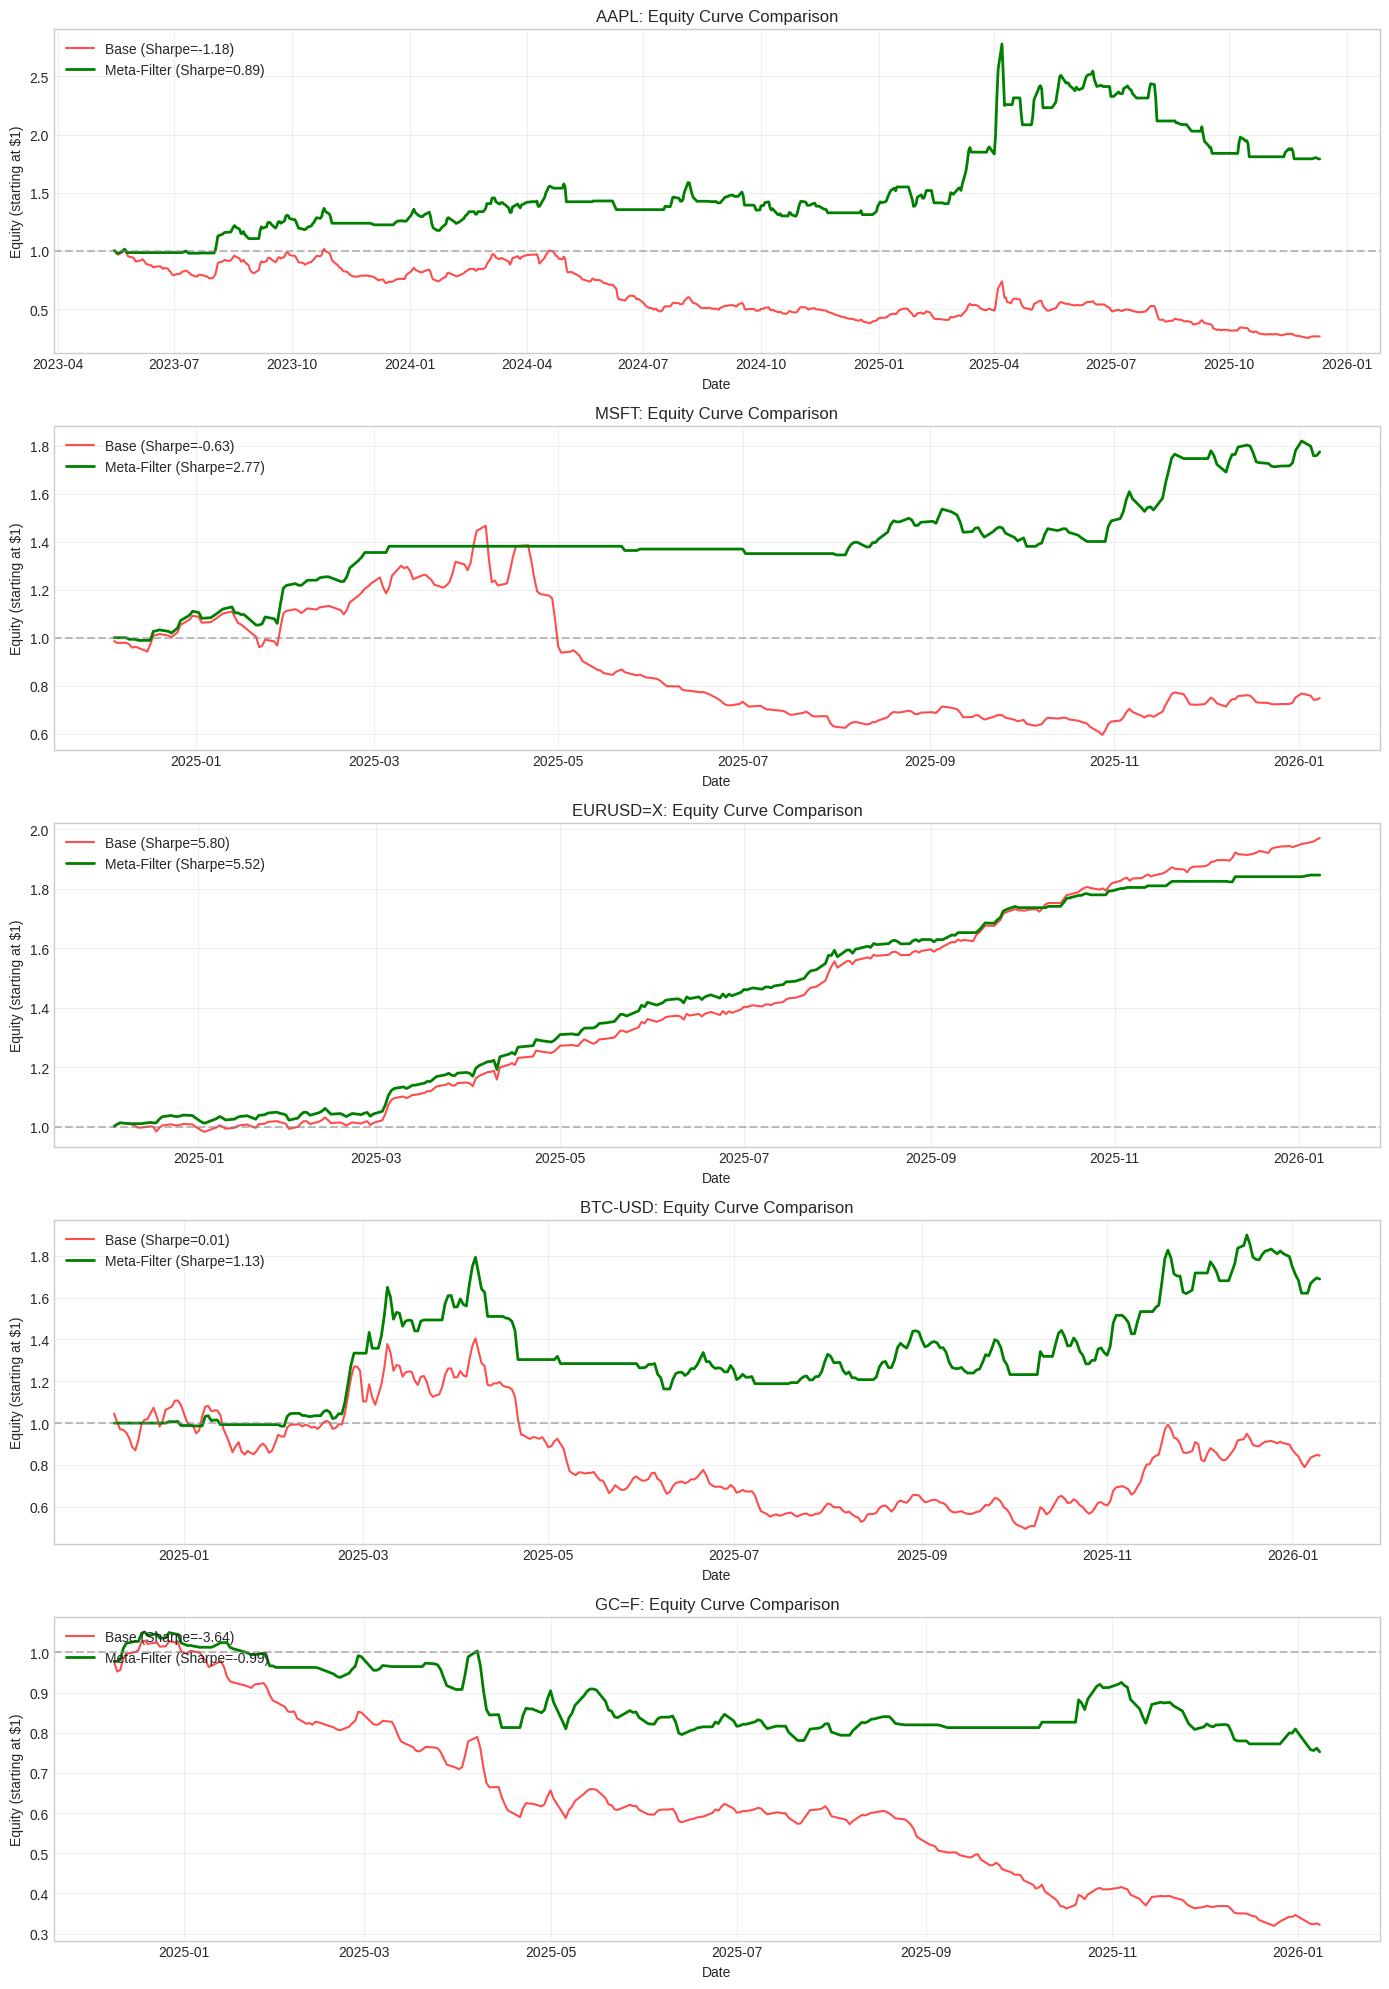

Saved: ../plots/equity_curves_all.png


In [11]:
# Plot equity curves for all tickers
n_tickers = len(TICKERS)
fig, axes = plt.subplots(n_tickers, 1, figsize=(14, 4*n_tickers))

if n_tickers == 1:
    axes = [axes]

for ax, ticker in zip(axes, TICKERS):
    res = META_RESULTS[ticker]
    test_data = res['test_data']
    tm = res['trading_metrics']
    
    ax.plot(test_data.index, test_data['Equity_Base'], 
            label=f'Base (Sharpe={tm["sharpe_base"]:.2f})', 
            color='red', alpha=0.7, linewidth=1.5)
    ax.plot(test_data.index, test_data['Equity_Meta'], 
            label=f'Meta-Filter (Sharpe={tm["sharpe_meta"]:.2f})', 
            color='green', linewidth=2)
    
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{ticker}: Equity Curve Comparison')
    ax.set_xlabel('Date')
    ax.set_ylabel('Equity (starting at $1)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'equity_curves_all.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/equity_curves_all.png")

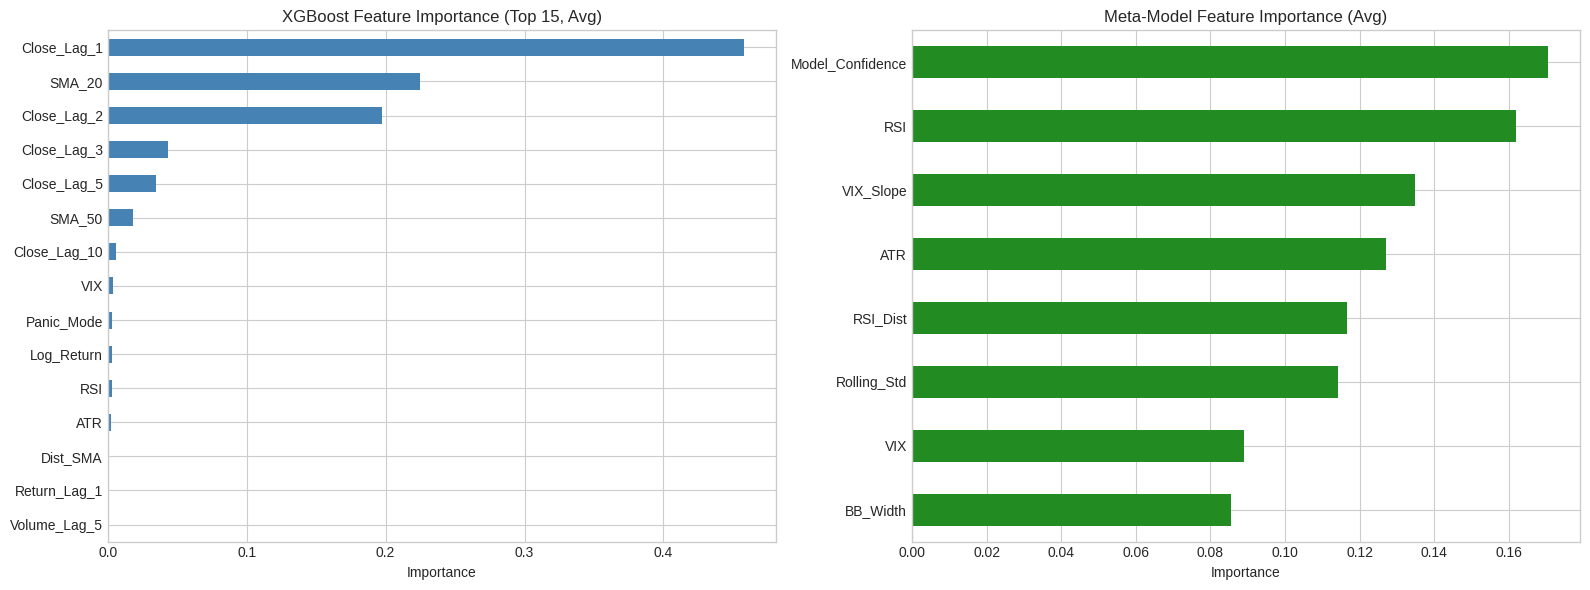

Saved: ../plots/feature_importance_comparison.png


In [12]:
# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost feature importance (average across tickers)
ax1 = axes[0]
xgb_importances = {}
for ticker, res in XGB_RESULTS.items():
    model = res['model']
    for i, feat in enumerate(res['feature_cols']):
        if feat not in xgb_importances:
            xgb_importances[feat] = []
        xgb_importances[feat].append(model.feature_importances_[i])

avg_xgb_imp = pd.Series({k: np.mean(v) for k, v in xgb_importances.items()}).sort_values(ascending=True)
avg_xgb_imp.tail(15).plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('XGBoost Feature Importance (Top 15, Avg)')
ax1.set_xlabel('Importance')

# Meta-model feature importance (average)
ax2 = axes[1]
meta_importances = {}
for ticker, res in META_RESULTS.items():
    for feat, imp in res['feature_importance'].items():
        if feat not in meta_importances:
            meta_importances[feat] = []
        meta_importances[feat].append(imp)

avg_meta_imp = pd.Series({k: np.mean(v) for k, v in meta_importances.items()}).sort_values(ascending=True)
avg_meta_imp.plot(kind='barh', ax=ax2, color='forestgreen')
ax2.set_title('Meta-Model Feature Importance (Avg)')
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'feature_importance_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/feature_importance_comparison.png")

## 6. SHAP Explainability

Computing SHAP values for AAPL...


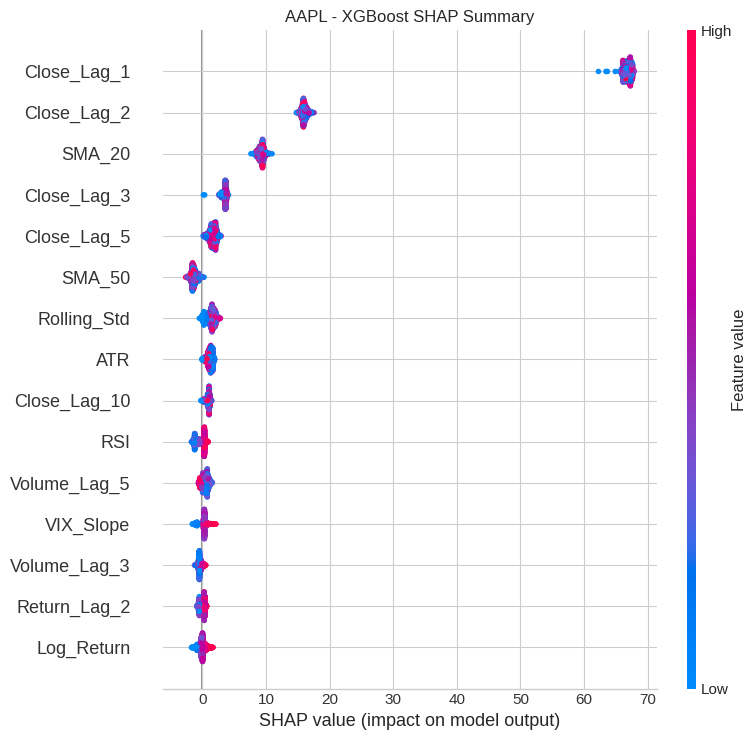

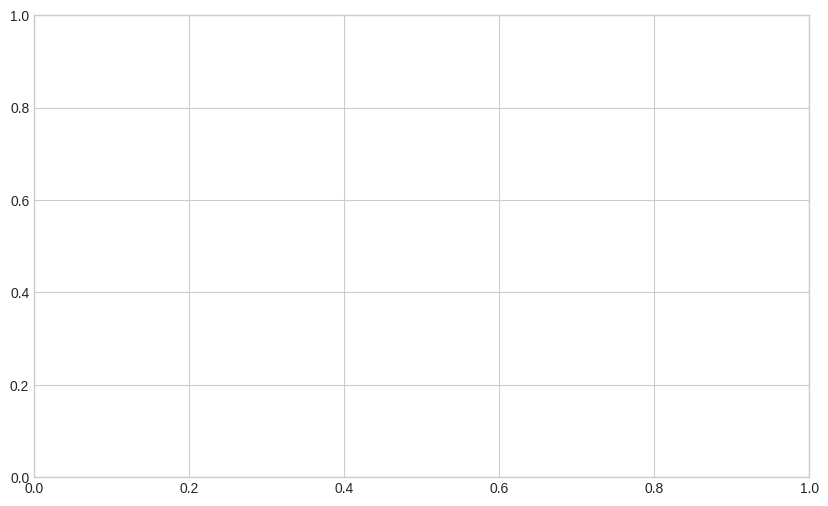

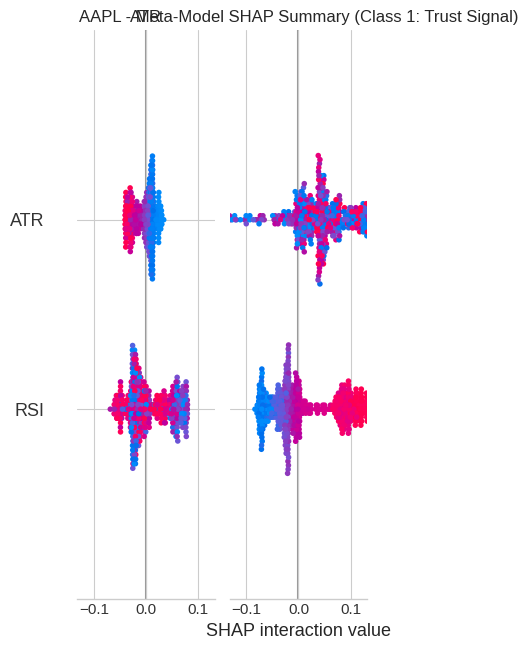


Saved SHAP plots to ../plots/


In [13]:
# SHAP analysis for one representative ticker (AAPL)
SHAP_TICKER = 'AAPL'

print(f"Computing SHAP values for {SHAP_TICKER}...")

# XGBoost SHAP
xgb_res = XGB_RESULTS[SHAP_TICKER]
xgb_explainer = shap.TreeExplainer(xgb_res['model'])
xgb_shap_values = xgb_explainer.shap_values(xgb_res['X_test'])

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(xgb_shap_values, xgb_res['X_test'], show=False, max_display=15)
plt.title(f'{SHAP_TICKER} - XGBoost SHAP Summary')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'shap_xgboost_{SHAP_TICKER}.png'), dpi=300, bbox_inches='tight')
plt.show()

# Meta-Model SHAP
meta_res = META_RESULTS[SHAP_TICKER]
meta_explainer = shap.TreeExplainer(meta_res['model'])
meta_shap_values = meta_explainer.shap_values(meta_res['X_m_test'])

# For binary classification, use class 1 values
if isinstance(meta_shap_values, list):
    meta_shap_vals = meta_shap_values[1]
else:
    meta_shap_vals = meta_shap_values

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(meta_shap_vals, meta_res['X_m_test'], show=False)
plt.title(f'{SHAP_TICKER} - Meta-Model SHAP Summary (Class 1: Trust Signal)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'shap_meta_{SHAP_TICKER}.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved SHAP plots to {PLOTS_DIR}/")

## 7. Save Models & Final Summary

In [14]:
# Save models
for ticker in TICKERS:
    # Save XGBoost
    xgb_path = os.path.join(MODELS_DIR, f'xgboost_{ticker.replace("=", "").replace("-", "")}.joblib')
    joblib.dump(XGB_RESULTS[ticker]['model'], xgb_path)
    
    # Save Meta-Model
    meta_path = os.path.join(MODELS_DIR, f'meta_rf_{ticker.replace("=", "").replace("-", "")}.joblib')
    joblib.dump(META_RESULTS[ticker]['model'], meta_path)

print(f"Models saved to {MODELS_DIR}/")
print(f"  - XGBoost models: xgboost_<ticker>.joblib")
print(f"  - Meta models: meta_rf_<ticker>.joblib")

Models saved to ../models/
  - XGBoost models: xgboost_<ticker>.joblib
  - Meta models: meta_rf_<ticker>.joblib


In [15]:
# Final comprehensive summary
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

print("\n[1] XGBoost Base Model (Regression)")
print("-" * 60)
for ticker, res in XGB_RESULTS.items():
    print(f"  {ticker:12} | RMSE: ${res['test_rmse']:>8.2f} | MAE: ${res['test_mae']:>8.2f} | Dir.Acc: {res['dir_accuracy']:>6.2%}")

print("\n[2] Meta-Model Filter Performance")
print("-" * 60)
for ticker, res in META_RESULTS.items():
    tm = res['trading_metrics']
    improvement = res['precision'] - res['base_accuracy']
    sign = '+' if improvement >= 0 else ''
    print(f"  {ticker:12} | Precision: {res['precision']:>6.2%} (Base: {res['base_accuracy']:.2%}, {sign}{improvement:.2%})")

print("\n[3] Trading Performance (Sharpe Ratio)")
print("-" * 60)
for ticker, res in META_RESULTS.items():
    tm = res['trading_metrics']
    sharpe_diff = tm['sharpe_meta'] - tm['sharpe_base']
    sign = '+' if sharpe_diff >= 0 else ''
    print(f"  {ticker:12} | Base: {tm['sharpe_base']:>5.2f} | Meta: {tm['sharpe_meta']:>5.2f} | Diff: {sign}{sharpe_diff:.2f}")

print("\n" + "="*80)
print("KEY INSIGHT: The Meta-Model acts as a confidence filter.")
print("When it says 'TRADE', we expect higher precision than blindly following XGBoost.")
print("="*80)


FINAL RESULTS SUMMARY

[1] XGBoost Base Model (Regression)
------------------------------------------------------------
  AAPL         | RMSE: $   72.21 | MAE: $   60.80 | Dir.Acc: 47.15%
  MSFT         | RMSE: $  105.84 | MAE: $   95.54 | Dir.Acc: 44.04%
  EURUSD=X     | RMSE: $    0.01 | MAE: $    0.00 | Dir.Acc: 70.21%
  BTC-USD      | RMSE: $30992.93 | MAE: $23244.15 | Dir.Acc: 54.77%
  GC=F         | RMSE: $ 1100.36 | MAE: $  867.15 | Dir.Acc: 40.92%

[2] Meta-Model Filter Performance
------------------------------------------------------------
  AAPL         | Precision: 53.85% (Base: 47.15%, +6.70%)
  MSFT         | Precision: 59.44% (Base: 44.04%, +15.40%)
  EURUSD=X     | Precision: 70.70% (Base: 70.21%, +0.48%)
  BTC-USD      | Precision: 53.28% (Base: 54.77%, -1.50%)
  GC=F         | Precision: 45.36% (Base: 41.10%, +4.25%)

[3] Trading Performance (Sharpe Ratio)
------------------------------------------------------------
  AAPL         | Base: -1.18 | Meta:  0.89 | Diff: 

---

## Conclusion

This notebook implements a **Hybrid Architecture** for time series prediction:

1. **Base Model (XGBoost)**: Regression model predicting next-day close price
   - Optimized via Optuna with TimeSeriesSplit cross-validation
   - Reports RMSE/MAE for regression task

2. **Meta-Model (Random Forest)**: Classification model that learns *when* to trust the base model
   - Trained on XGBoost's historical accuracy
   - Filters out unreliable trading signals
   - Reports Precision, Directional Accuracy, Sharpe Ratio

**Key Features:**
- Multi-asset support (5 different signals)
- VIX integration for market regime detection
- SHAP explainability for both models
- Comprehensive trading metrics

---